# 1. PVT-модель газа

В этом разделе показаны зависимости основных свойств газа от давления:
- Z-фактор
- Плотность газа
- Объёмный коэффициент B_g
- Вязкость газа

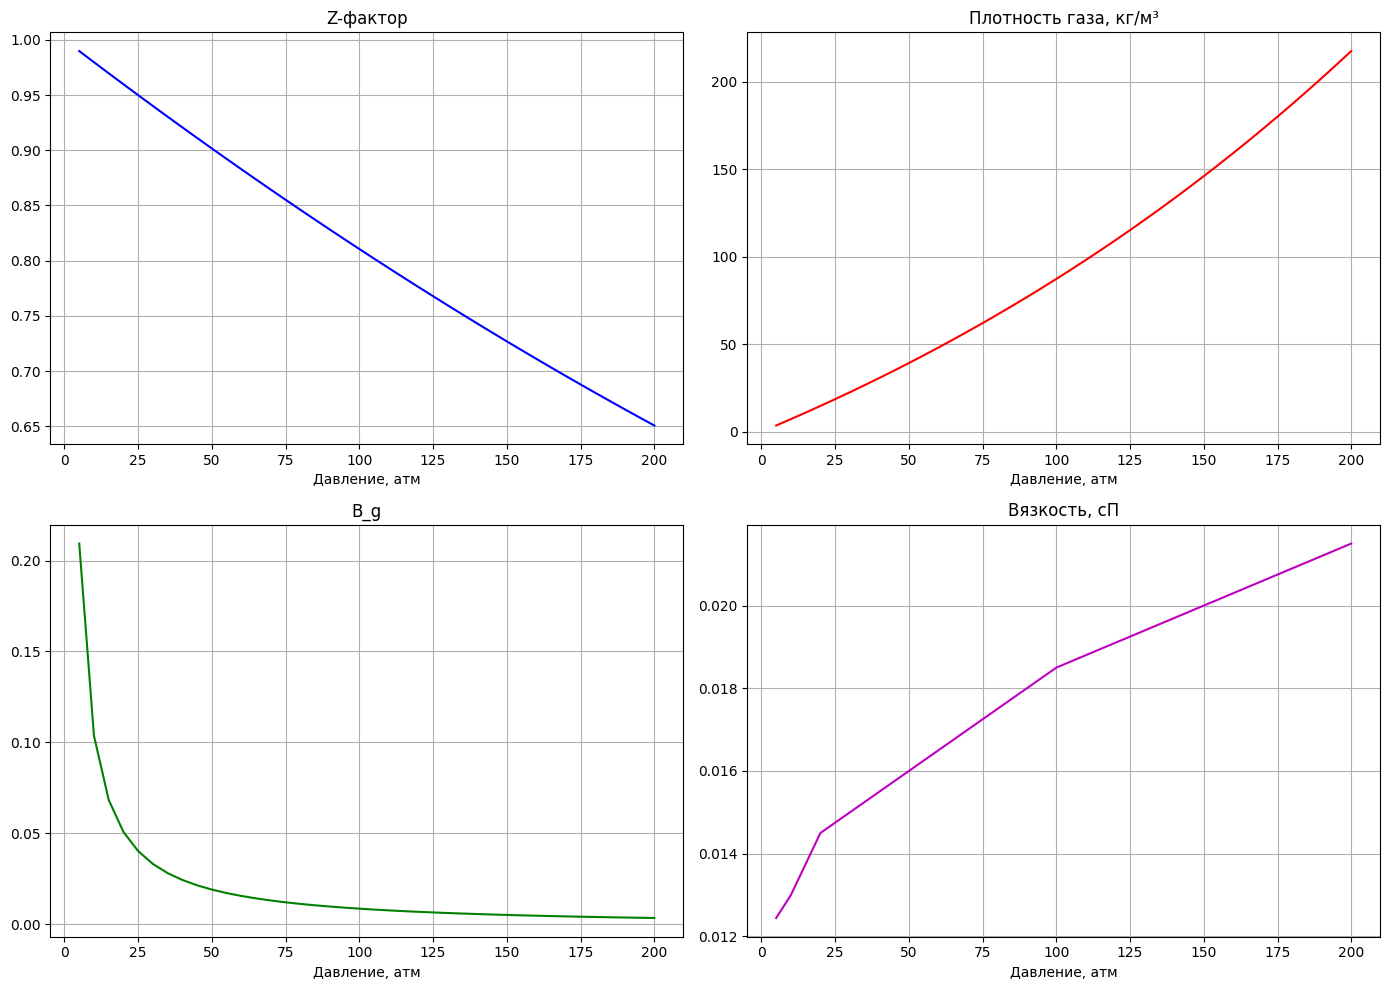

In [7]:
import matplotlib.pyplot as plt
from src.fluid import Fluid

fluid = Fluid()
P = list(range(5, 201, 5))

Z = [fluid.z(p) for p in P]
ro = [fluid.ro(p) for p in P]
bg = [fluid.bg(p) for p in P]
mu = [fluid.mu(p) for p in P]

plt.figure(figsize=(14, 10))

plt.subplot(2, 2, 1)
plt.plot(P, Z, 'b-')
plt.title("Z-фактор")
plt.xlabel("Давление, атм")
plt.grid(True)

plt.subplot(2, 2, 2)
plt.plot(P, ro, 'r-')
plt.title("Плотность газа, кг/м³")
plt.xlabel("Давление, атм")
plt.grid(True)

plt.subplot(2, 2, 3)
plt.plot(P, bg, 'g-')
plt.title("B_g")
plt.xlabel("Давление, атм")
plt.grid(True)

plt.subplot(2, 2, 4)
plt.plot(P, mu, 'm-')
plt.title("Вязкость, сП")
plt.xlabel("Давление, атм")
plt.grid(True)

plt.tight_layout()
plt.show()

# 2. IPR-кривая (кривая притока)

IPR показывает, как меняется дебит скважины в зависимости от забойного давления.

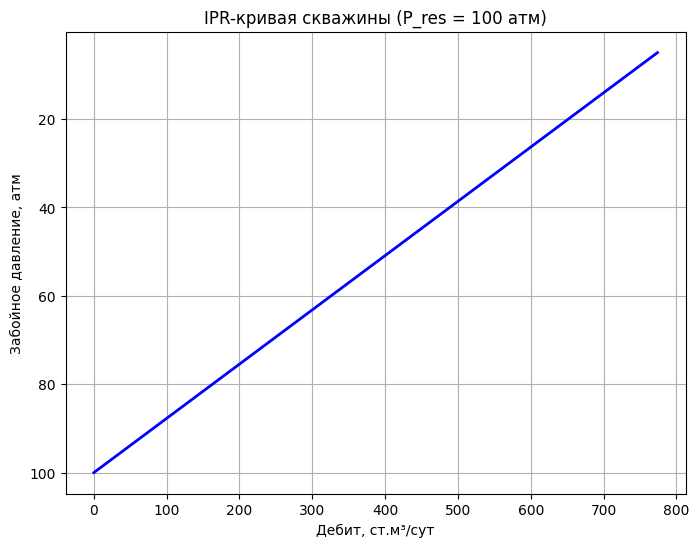

In [8]:
from src.fluid import Fluid
from src.well import Well

fluid = Fluid()

# Создаём одну скважину (без трубы для простоты)
well = Well(fluid, k=50, h=25, re=500, rw=0.1)

P_res = 100  # пластовое давление
P_bhp_list = list(range(5, 101, 5))

q_list = [well.q(P_res, p) for p in P_bhp_list]

plt.figure(figsize=(8, 6))
plt.plot(q_list, P_bhp_list, 'b-', linewidth=2)
plt.xlabel("Дебит, ст.м³/сут")
plt.ylabel("Забойное давление, атм")
plt.title("IPR-кривая скважины (P_res = 100 атм)")
plt.grid(True)
plt.gca().invert_yaxis()  # чтобы давление уменьшалось вниз
plt.show()


# 3. VLP 
VLP показывает перепад давления в НКТ в зависимости от дебита.


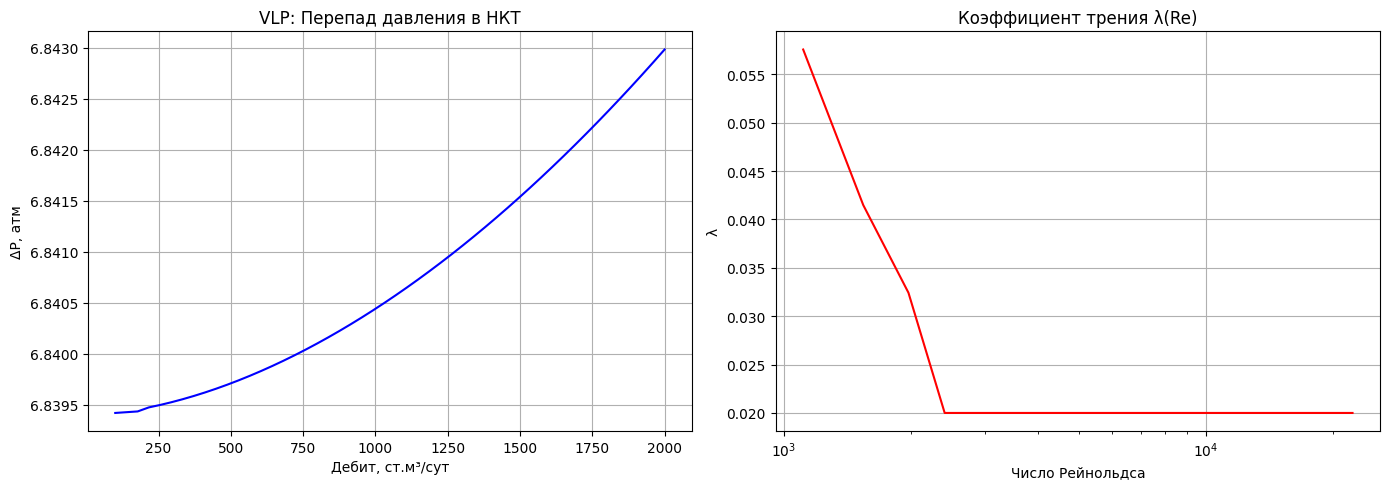

In [23]:
from src.fluid import Fluid
from src.pipe import Pipe
import numpy as np

fluid = Fluid()

# Параметры НКТ (примерно как у первой скважины)
pipe = Pipe(L=2000, D=0.062, roughness=0.000046, fluid=fluid, vertical_depth=1800)

q_list = np.linspace(100, 2000, 50)
dp_list = []
lam_list = []
Re_list = []

for q in q_list:
    state = pipe.dp(50, q)  # давление на входе 50 атм
    dp_list.append(state.dP)
    Re_list.append((state.rho * state.v * pipe.D) / (fluid.mu(50)/1000) if state.v > 0 else 1)
    
    # Коэффициент трения (упрощённо)
    if Re_list[-1] < 2300:
        lam = 64 / Re_list[-1]
    else:
        lam = 0.02  # примерно
    lam_list.append(lam)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(q_list, dp_list, 'b-')
plt.title("VLP: Перепад давления в НКТ")
plt.xlabel("Дебит, ст.м³/сут")
plt.ylabel("ΔP, атм")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(Re_list, lam_list, 'r-')
plt.title("Коэффициент трения λ(Re)")
plt.xlabel("Число Рейнольдса")
plt.ylabel("λ")
plt.xscale('log')
plt.grid(True)

plt.tight_layout()
plt.show()

# 4. Рабочая точка (IPR + VLP)

На графике показаны кривая притока (IPR) и кривая подъёма (VLP). 
Точка их пересечения — рабочая точка скважины.

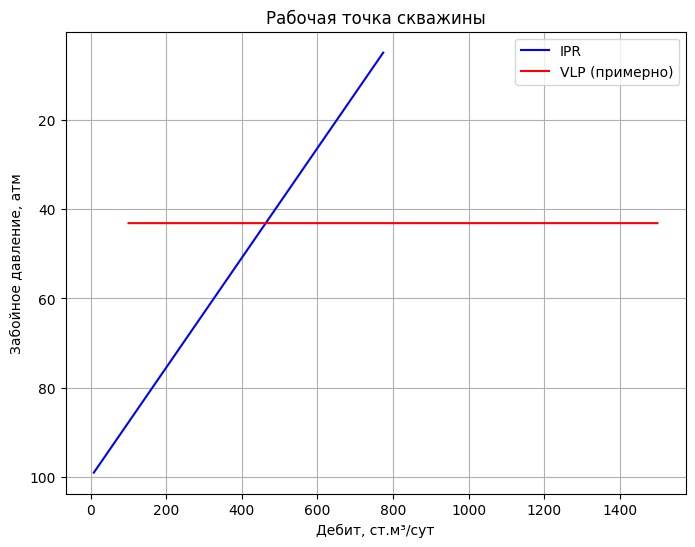

In [22]:
from src.fluid import Fluid
from src.well import Well
from src.pipe import Pipe
import numpy as np

fluid = Fluid()

# Скважина + труба
pipe = Pipe(L=2000, D=0.062, roughness=0.000046, fluid=fluid, vertical_depth=1800)
well = Well(fluid, k=50, h=25, re=500, rw=0.1, pipe=pipe)

P_res = 100
P_bhp_list = np.linspace(5, 99, 50)

# IPR
q_ipr = [well.q(P_res, p) for p in P_bhp_list]

# VLP (примерно)
q_vlp = np.linspace(100, 1500, 50)
dp_vlp = []
for q in q_vlp:
    state = pipe.dp(50, q)
    dp_vlp.append(state.dP)

plt.figure(figsize=(8, 6))
plt.plot(q_ipr, P_bhp_list, 'b-', label='IPR')
plt.plot(q_vlp, 50 - np.array(dp_vlp), 'r-', label='VLP (примерно)')
plt.xlabel("Дебит, ст.м³/сут")
plt.ylabel("Забойное давление, атм")
plt.title("Рабочая точка скважины")
plt.legend()
plt.grid(True)
plt.gca().invert_yaxis()
plt.show()

# 5. Динамика добычи (180 дней)

Здесь показана работа месторождения в течение 180 дней:
- Падение пластового давления
- Дебит скважин
- Накопленная добыча

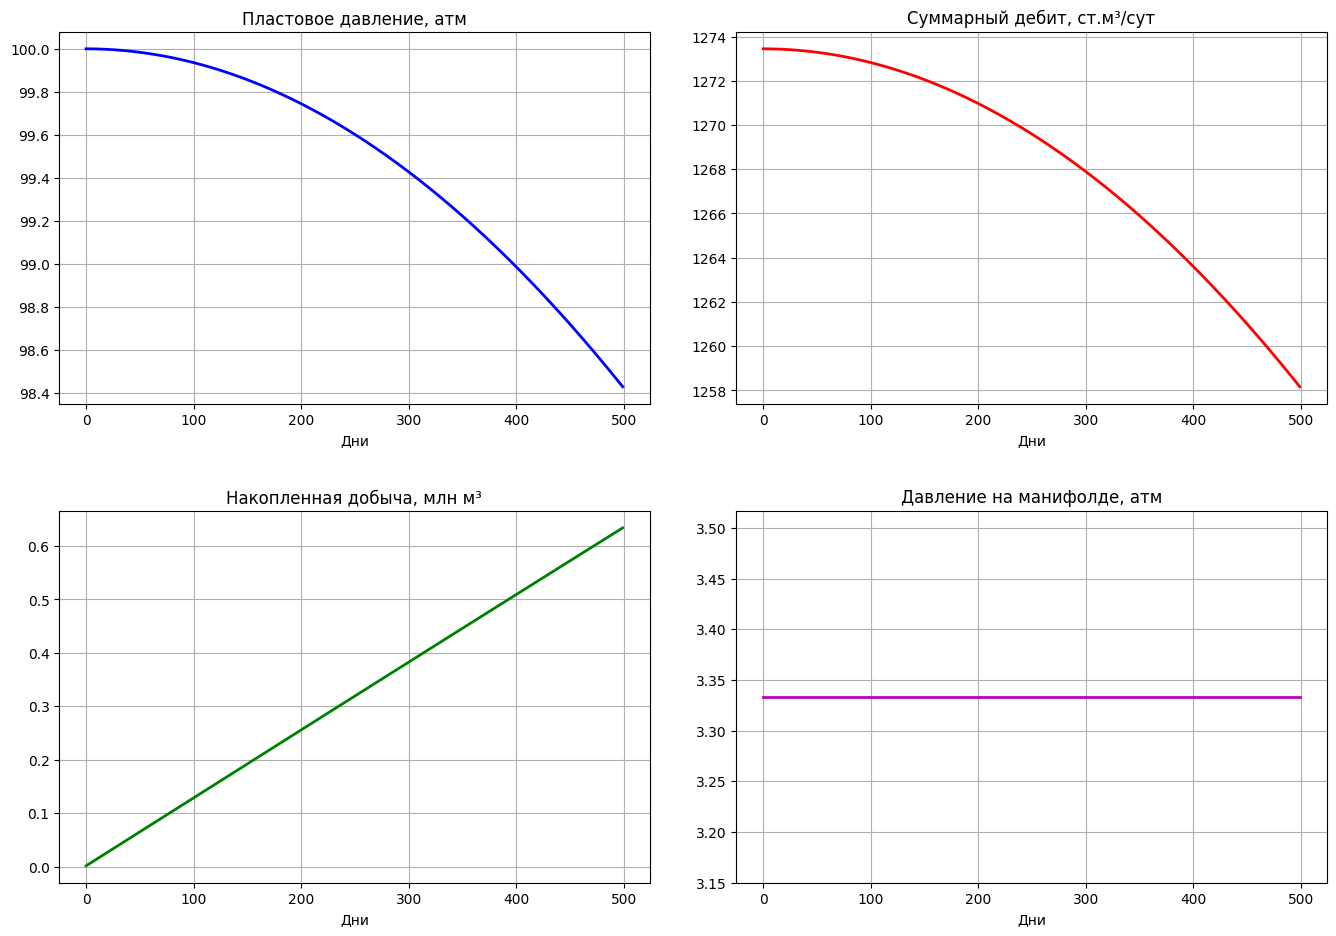

In [11]:
from src.fluid import Fluid
from src.reservoir import Reservoir, ResProps
from src.pipe import Pipe
from src.well import Well
from src.compressor import DCS
from src.simulator import FieldSimulator
import matplotlib.pyplot as plt

fluid = Fluid()

pipe1 = Pipe(L=2000, D=0.062, roughness=0.000046, fluid=fluid, vertical_depth=1800)
pipe2 = Pipe(L=2500, D=0.062, roughness=0.000046, fluid=fluid, vertical_depth=1900)
pipe3 = Pipe(L=1800, D=0.073, roughness=0.000046, fluid=fluid, vertical_depth=1600)

well1 = Well(fluid, k=30, h=20, re=400, rw=0.1, pipe=pipe1)
well2 = Well(fluid, k=30, h=20, re=400, rw=0.1, pipe=pipe2)
well3 = Well(fluid, k=30, h=20, re=400, rw=0.1, pipe=pipe3)

shlyf = Pipe(L=5000, D=0.200, roughness=0.000046, fluid=fluid, vertical_depth=0.0)
dcs = DCS(CR=1.5, P_line=5.0, q_ext=300.0)

sim = FieldSimulator(Reservoir(ResProps(P=100.0, V=8_000_000, T=310.0), fluid), 
                     [well1, well2, well3], shlyf, dcs)

df = sim.run(500, dt=1.0)

fig, axs = plt.subplots(2, 2, figsize=(14, 10))

# Убираем научную нотацию
for ax in axs.flat:
    ax.ticklabel_format(useOffset=False, style='plain')

axs[0, 0].plot(df['t'], df['P_res'], 'b-', linewidth=2)
axs[0, 0].set_title("Пластовое давление, атм")
axs[0, 0].set_xlabel("Дни")
axs[0, 0].grid(True)

axs[0, 1].plot(df['t'], df['q_total'], 'r-', linewidth=2)
axs[0, 1].set_title("Суммарный дебит, ст.м³/сут")
axs[0, 1].set_xlabel("Дни")
axs[0, 1].grid(True)

axs[1, 0].plot(df['t'], df['Gp'], 'g-', linewidth=2)
axs[1, 0].set_title("Накопленная добыча, млн м³")
axs[1, 0].set_xlabel("Дни")
axs[1, 0].grid(True)

axs[1, 1].plot(df['t'], df['P_man'], 'm-', linewidth=2)
axs[1, 1].set_title("Давление на манифолде, атм")
axs[1, 1].set_xlabel("Дни")
axs[1, 1].grid(True)

plt.tight_layout(pad=3.0)
plt.show()

# 6. Влияние степени сжатия ДКС (CR)

В этом разделе показано, как меняется работа системы при разных значениях степени сжатия ДКС (CR = 1.0, 1.5, 2.0).

CR — это во сколько раз ДКС повышает давление. Чем выше CR, тем ниже давление на входе в ДКС, и тем выше может быть дебит скважин.

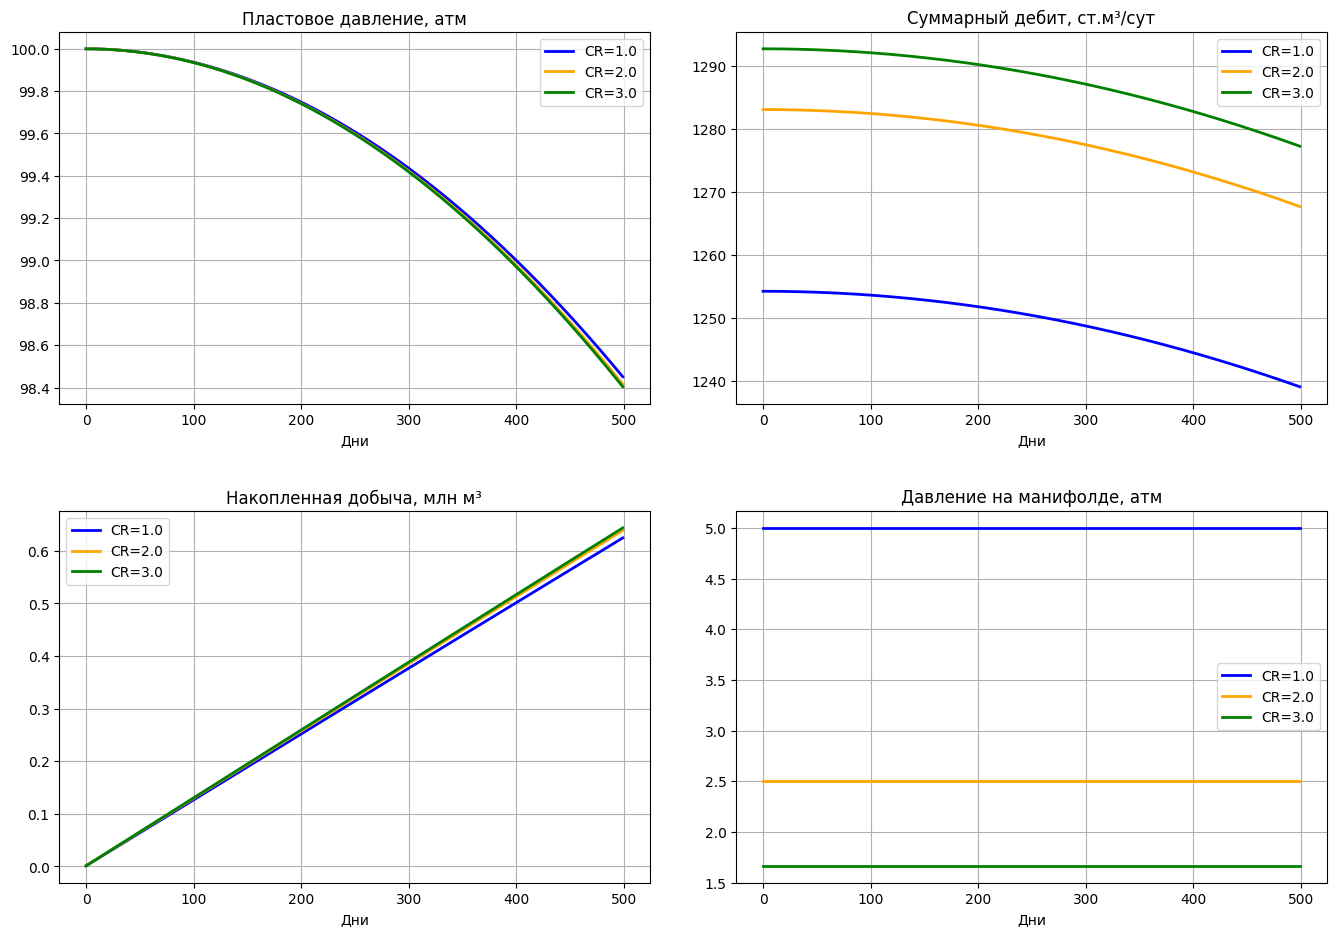

In [12]:
from src.fluid import Fluid
from src.reservoir import Reservoir, ResProps
from src.pipe import Pipe
from src.well import Well
from src.compressor import DCS
from src.simulator import FieldSimulator
import matplotlib.pyplot as plt

fluid = Fluid()

pipe1 = Pipe(L=2000, D=0.062, roughness=0.000046, fluid=fluid, vertical_depth=1800)
pipe2 = Pipe(L=2500, D=0.062, roughness=0.000046, fluid=fluid, vertical_depth=1900)
pipe3 = Pipe(L=1800, D=0.073, roughness=0.000046, fluid=fluid, vertical_depth=1600)

well1 = Well(fluid, k=30, h=20, re=400, rw=0.1, pipe=pipe1)
well2 = Well(fluid, k=30, h=20, re=400, rw=0.1, pipe=pipe2)
well3 = Well(fluid, k=30, h=20, re=400, rw=0.1, pipe=pipe3)

shlyf = Pipe(L=5000, D=0.200, roughness=0.000046, fluid=fluid, vertical_depth=0.0)

fig, axs = plt.subplots(2, 2, figsize=(14, 10))

for ax in axs.flat:
    ax.ticklabel_format(useOffset=False, style='plain')

for CR, color in [(1.0, 'blue'), (2.0, 'orange'), (3.0, 'green')]:
    dcs = DCS(CR=CR, P_line=5.0, q_ext=300.0)
    reservoir = Reservoir(ResProps(P=100.0, V=8_000_000, T=310.0), fluid)
    sim = FieldSimulator(reservoir, [well1, well2, well3], shlyf, dcs)
    df = sim.run(500, dt=1.0)
    
    axs[0, 0].plot(df['t'], df['P_res'], label=f'CR={CR}', color=color, linewidth=2)
    axs[0, 1].plot(df['t'], df['q_total'], label=f'CR={CR}', color=color, linewidth=2)
    axs[1, 0].plot(df['t'], df['Gp'], label=f'CR={CR}', color=color, linewidth=2)
    axs[1, 1].plot(df['t'], df['P_man'], label=f'CR={CR}', color=color, linewidth=2)

axs[0, 0].set_title("Пластовое давление, атм")
axs[0, 0].set_xlabel("Дни")
axs[0, 0].legend()
axs[0, 0].grid(True)

axs[0, 1].set_title("Суммарный дебит, ст.м³/сут")
axs[0, 1].set_xlabel("Дни")
axs[0, 1].legend()
axs[0, 1].grid(True)

axs[1, 0].set_title("Накопленная добыча, млн м³")
axs[1, 0].set_xlabel("Дни")
axs[1, 0].legend()
axs[1, 0].grid(True)

axs[1, 1].set_title("Давление на манифолде, атм")
axs[1, 1].set_xlabel("Дни")
axs[1, 1].legend()
axs[1, 1].grid(True)

plt.tight_layout(pad=3.0)
plt.show()

# 7. Калибровка модели

В этом разделе проводится сравнение результатов модели с условными промысловыми данными (для демонстрации метода).

Для калибровки используется среднеквадратичная ошибка (RMSE) и коэффициент детерминации (R²).

Дебит:    RMSE = 2.0 ст.м³/сут,  R² = 0.848
Давление: RMSE = 0.10 атм,     R² = 0.953


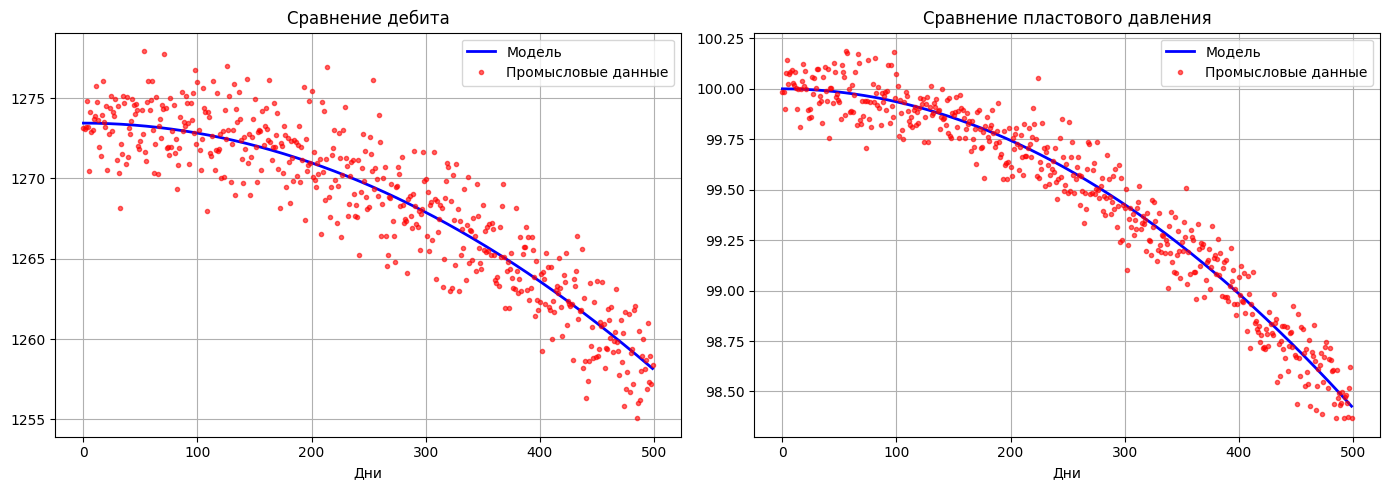

In [13]:
from src.fluid import Fluid
from src.reservoir import Reservoir, ResProps
from src.pipe import Pipe
from src.well import Well
from src.compressor import DCS
from src.simulator import FieldSimulator
import matplotlib.pyplot as plt
import random
import math

fluid = Fluid()

pipe1 = Pipe(L=2000, D=0.062, roughness=0.000046, fluid=fluid, vertical_depth=1800)
pipe2 = Pipe(L=2500, D=0.062, roughness=0.000046, fluid=fluid, vertical_depth=1900)
pipe3 = Pipe(L=1800, D=0.073, roughness=0.000046, fluid=fluid, vertical_depth=1600)

well1 = Well(fluid, k=30, h=20, re=400, rw=0.1, pipe=pipe1)
well2 = Well(fluid, k=30, h=20, re=400, rw=0.1, pipe=pipe2)
well3 = Well(fluid, k=30, h=20, re=400, rw=0.1, pipe=pipe3)

shlyf = Pipe(L=5000, D=0.200, roughness=0.000046, fluid=fluid, vertical_depth=0.0)
dcs = DCS(CR=1.5, P_line=5.0, q_ext=300.0)

sim = FieldSimulator(Reservoir(ResProps(P=100.0, V=8_000_000, T=310.0), fluid), 
                     [well1, well2, well3], shlyf, dcs)

df = sim.run(500, dt=1.0)

# === "Промысловые" данные ===
random.seed(42)
q_real = [q + random.gauss(0, 2) for q in df['q_total']]
P_real = [p + random.gauss(0, 0.1) for p in df['P_res']]

def mean(lst):
    return sum(lst) / len(lst)

def r2_score_manual(y_true, y_pred):
    y_mean = mean(y_true)
    ss_res = sum((yt - yp)**2 for yt, yp in zip(y_true, y_pred))
    ss_tot = sum((yt - y_mean)**2 for yt in y_true)
    return 1 - (ss_res / ss_tot)

def rmse(y_true, y_pred):
    return math.sqrt(sum((yt - yp)**2 for yt, yp in zip(y_true, y_pred)) / len(y_true))

rmse_q = rmse(q_real, list(df['q_total']))
r2_q = r2_score_manual(q_real, list(df['q_total']))

rmse_p = rmse(P_real, list(df['P_res']))
r2_p = r2_score_manual(P_real, list(df['P_res']))

print(f"Дебит:    RMSE = {rmse_q:.1f} ст.м³/сут,  R² = {r2_q:.3f}")
print(f"Давление: RMSE = {rmse_p:.2f} атм,     R² = {r2_p:.3f}")

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(df['t'], df['q_total'], 'b-', linewidth=2, label='Модель')
plt.plot(df['t'], q_real, 'r.', alpha=0.6, label='Промысловые данные')
plt.title("Сравнение дебита")
plt.xlabel("Дни")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(df['t'], df['P_res'], 'b-', linewidth=2, label='Модель')
plt.plot(df['t'], P_real, 'r.', alpha=0.6, label='Промысловые данные')
plt.title("Сравнение пластового давления")
plt.xlabel("Дни")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()